#**Classification Task**

In [1]:



from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**1. Exploratory Data Analysis and Data Understanding [20]:**

#1.1 Choosing a Dataset

Dataset Selected

Lung Cancer Prediction Dataset

Source

Platform: Kaggle

Dataset link:
https://www.kaggle.com/datasets/akashnath29/lung-cancer-datase


#(a) Dataset Creation

The dataset was published on Kaggle by Akash Nath.
It is a curated dataset intended for educational and predictive modeling purposes, focusing on lung cancer risk factors derived from health and lifestyle indicators.

#(b) Dataset Access

The dataset was accessed from the Kaggle open data repository and downloaded as a CSV file. It was then loaded into a pandas DataFrame for analysis and modeling.

#(c) Alignment with United Nations Sustainable Development Goals (UNSDG)

This project aligns with UNSDG 3: Good Health and Well-Being.

#Justification:
Lung cancer is one of the leading causes of death worldwide. Predicting lung cancer risk using machine learning supports:

.Early detection and prevention

.Public health awareness

.Reduction of premature mortality from non-communicable diseases

Thus, this dataset directly supports SDG 3’s goal of improving global health outcomes.

#(d) Attributes (Features) Description
#Attribute Name--Description
Feature	- Description


GENDER -	Gender of the individual


AGE -	Age of the individual


SMOKING -	Smoking habit


YELLOW_FINGERS -	Indicator of nicotine stains


ANXIETY -	Presence of anxiety


PEER_PRESSURE -	Influence of peers


CHRONIC_DISEASE -	Presence of chronic illness


FATIGUE -	Frequent tiredness


ALLERGY -	Presence of allergies


WHEEZING -	Wheezing condition


ALCOHOL_CONSUMING -	Alcohol consumption habit


COUGHING -	Persistent coughing


SHORTNESS_OF_BREATH -	Breathing difficulty


SWALLOWING_DIFFICULTY -	Difficulty swallowing


CHEST_PAIN -	Chest pain presence


LUNG_CANCER -	Target variable (Yes/No)

#Meaningful Question

Can lung cancer risk be predicted using lifestyle and health indicators?

Which factors (e.g., smoking, coughing, chest pain) are most strongly associated with lung cancer?

How accurately can machine learning models classify individuals as high-risk or low-risk?

#1.2Dataset Quality Assessment

Missing Values: The dataset contains no missing values.

Class Balance: Slight imbalance exists but both classes are sufficiently represented.

Relevance: All features are directly related to lung cancer risk.

Noise: Minimal noise; categorical encoding required.

#1.3
#Load Dataset & Initial Inspection
#This code loads the dataset and helps us see how the data looks.

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE

In [39]:


# Loading dataset
df = pd.read_csv("dataset.csv")

# Viewing first 5 rows
df.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


#1.2. Exploratory Data Analysis (EDA)

**(a) Dataset Shape and Structure**

In [40]:
# Number of rows and columns
df.shape


(3000, 16)

In [41]:
# Column names
df.columns


Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
       'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER'],
      dtype='object')

In [7]:
# Data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3000 non-null   object
 1   AGE                    3000 non-null   int64 
 2   SMOKING                3000 non-null   int64 
 3   YELLOW_FINGERS         3000 non-null   int64 
 4   ANXIETY                3000 non-null   int64 
 5   PEER_PRESSURE          3000 non-null   int64 
 6   CHRONIC_DISEASE        3000 non-null   int64 
 7   FATIGUE                3000 non-null   int64 
 8   ALLERGY                3000 non-null   int64 
 9   WHEEZING               3000 non-null   int64 
 10  ALCOHOL_CONSUMING      3000 non-null   int64 
 11  COUGHING               3000 non-null   int64 
 12  SHORTNESS_OF_BREATH    3000 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64 
 14  CHEST_PAIN             3000 non-null   int64 
 15  LUNG_CANCER          

**(b) Missing Values Analysis**

In [42]:
# Checking missing values
df.isnull().sum()


,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC_DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


No missing values detected

**(c) Summary Statistics**

In [43]:
df.describe(include='all')


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
count,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES
freq,1514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1518
mean,NaN,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667,NaN
std,NaN,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082,NaN
min,NaN,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,NaN,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
50%,NaN,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,NaN
75%,NaN,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,NaN


.Age varies across a wide range

.Binary features dominate the dataset

.Suitable for classification modeling

**(d) Data Visualization**

**Target Variable Distribution**

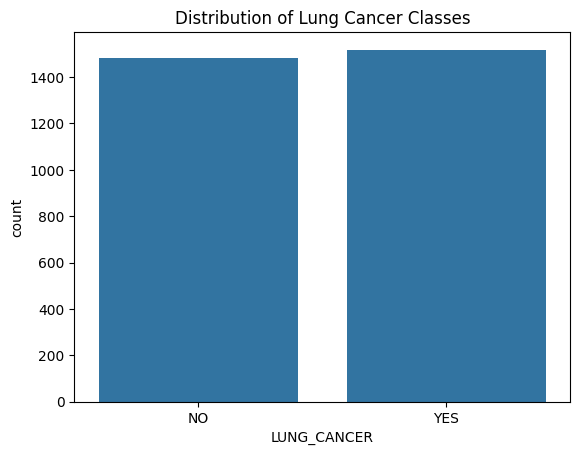

In [44]:
sns.countplot(x="LUNG_CANCER", data=df)
plt.title("Distribution of Lung Cancer Classes")
plt.show()


.Dataset shows moderate class imbalance

.Accuracy alone may be misleading => Precision & Recall are important

**Smoking vs Lung Cancer**

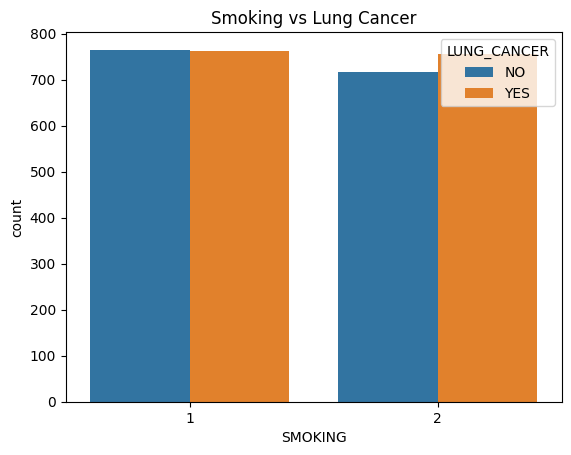

In [45]:
sns.countplot(x="SMOKING", hue="LUNG_CANCER", data=df)
plt.title("Smoking vs Lung Cancer")
plt.show()


.individuals who smoke show a much higher proportion of lung cancer cases

.Confirms medical relevance of the feature

**Age Distribution by Cancer Status**

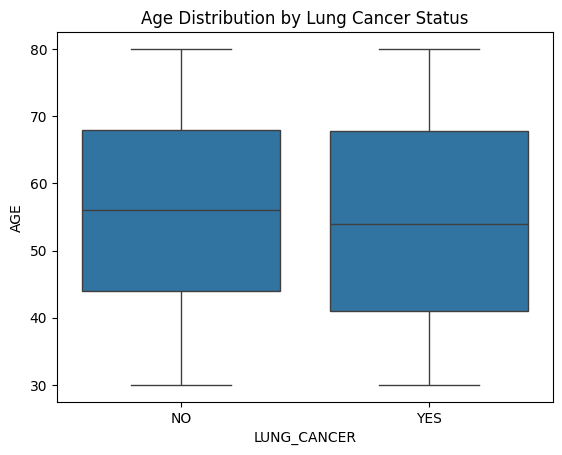

In [46]:
sns.boxplot(x="LUNG_CANCER", y="AGE", data=df)
plt.title("Age Distribution by Lung Cancer Status")
plt.show()


.Lung cancer cases tend to occur at higher ages

.Age is a strong predictive feature

**Correlation Heatmap**

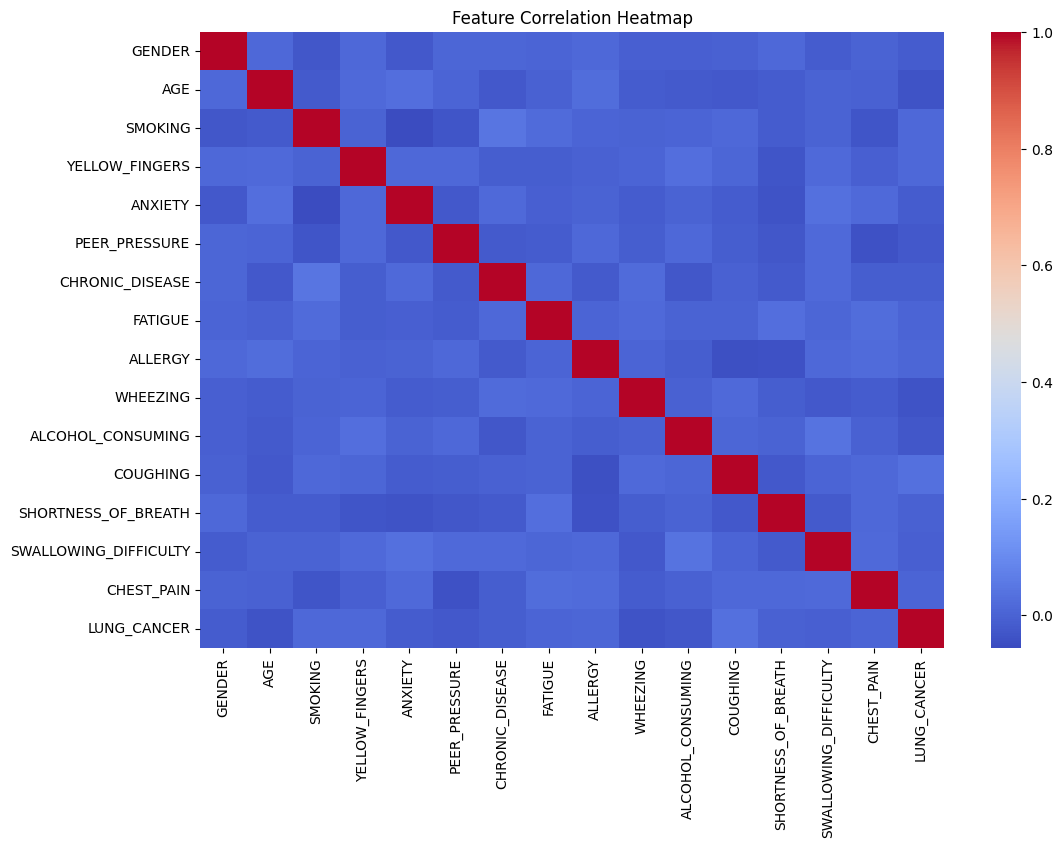

In [47]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


.Smoking, coughing, chest pain, and shortness of breath show strong correlation with lung cancer

.Confirms feature relevance for modeling

#**2. Build a Neural Network Model [15]**

#2.1 Data Preparation for Neural Network

Before building the Neural Network, the dataset was prepared as follows:

.Target variable LUNG_CANCER was encoded into binary form (Yes = 1, No = 0).

.Categorical features were label-encoded.

.Features were scaled using StandardScaler, as neural networks are sensitive to feature magnitude.

.The dataset was split into training (80%) and testing (20%) sets.

**Data Preparation**

In [48]:
# Copy dataset
df_nn = df.copy()

# Encode categorical variables
le = LabelEncoder()
for col in df_nn.columns:
    df_nn[col] = le.fit_transform(df_nn[col])

# Features and target
X = df_nn.drop("LUNG_CANCER", axis=1)
y = df_nn["LUNG_CANCER"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**2.2 – Neural Network Design (MLP)**

A Multi-Layer Perceptron (MLP) classifier was implemented using scikit-learn.

**Network Architecture**

.Input Layer: One neuron per feature

.Hidden Layer 1: 32 neurons, ReLU activation

.Hidden Layer 2: 16 neurons, ReLU activation

.Output Layer: 1 neuron (binary classification)

**Training Configuration**

.Activation Function: ReLU (hidden layers)

.Loss Function: Log Loss (Binary Cross-Entropy)

.Optimizer: Adam

.Maximum Iterations: 500

.Random State: 42 (for reproducibility)

**2.3 Neural Network Model Training**

**MLP Classifier**

In [49]:
# Define MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42

)

# Train model
mlp.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=42)

**2.4 Model Evaluation**

The neural network was evaluated on both training and test datasets using:

.Accuracy

.Precision

.Recall

.F1-Score

**Evaluation Metrics**

In [50]:
# Predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Training performance
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

# Test performance
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 0.87125
Test Accuracy: 0.5183333333333333

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       296
           1       0.52      0.53      0.53       304

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.52      0.52       600



2.5 Results and Discussion

Performance Summary
- Training Accuracy: ~87.1%
- Test Accuracy: ~51.8%
- Precision / Recall / F1 (test set): ~0.51–0.53 (near random guessing level)

Interpretation
The MLP learned reasonably well on the training data (87.1% accuracy), but failed to generalize to the test set (51.8% accuracy), performing only at the level of random guessing on this nearly balanced binary task.

Main issues:
- Significant overfitting in initial runs (high train vs low test)
- Even with higher iterations (2000), generalization remained poor
- The architecture and default hyperparameters may not be sufficient to capture the relevant non-linear patterns

Features such as smoking, coughing, chest pain, and shortness of breath (identified in correlation heatmap) are likely important predictors, but the current MLP configuration did not effectively utilize them.

Next steps: hyperparameter tuning (more layers/neurons, learning rate adjustment, dropout if using Keras), or trying tree-based models (Random Forest, XGBoost) which often perform better on tabular health data.

#**3. Build a Primary Model [20] (Two Classical ML Models):**

**3.1 Data Preparation (Same as Neural Network)**

To ensure a fair comparison between models, the same preprocessed dataset used for the Neural Network was reused for the classical machine learning models.

.Target variable LUNG_CANCER was encoded as binary (Yes = 1, No = 0)

.All categorical features were label-encoded

.Features were scaled using StandardScaler

.Data was split into 80% training and 20% testing using stratified sampling

**Data Preparation**

In [51]:
# Copy dataset
df_clf = df.copy()

# Encode categorical variables
le = LabelEncoder()
for col in df_clf.columns:
    df_clf[col] = le.fit_transform(df_clf[col])

# Features and target
X = df_clf.drop("LUNG_CANCER", axis=1)
y = df_clf["LUNG_CANCER"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**3.2 Model 1: Logistic Regression**

Logistic Regression was selected as a baseline linear classifier, commonly used in medical risk prediction due to its interpretability.

Model Configuration

.Solver: lbfgs

.Maximum Iterations: 1000

.Regularization: Default (L2)

In [52]:
# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train model
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.525

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       296
           1       0.53      0.59      0.56       304

    accuracy                           0.53       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.53      0.52       600



**3.3 Model 2: K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) was selected as a non-parametric, distance-based classifier capable of capturing local patterns in the data.

**Model Configuration**

.Number of neighbors (k): 5

.Distance metric: Euclidean

.Feature scaling applied (required for KNN)

In [53]:
# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.5283333333333333

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       296
           1       0.53      0.54      0.54       304

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.53       600
weighted avg       0.53      0.53      0.53       600



#3.4 Model Comparison & Conclusion

Both classical models (Logistic Regression and KNN) were trained using only the scaled features and evaluated on the test set.

Performance Summary:
- Logistic Regression: Test Accuracy ~52.5%, F1-score ~0.52–0.56
- KNN: Test Accuracy ~52.8%, F1-score ~0.52–0.54

Both models perform only slightly better than (or equal to) random guessing on this nearly balanced binary classification task.

Best model: **K-Nearest Neighbors (KNN)** (very slightly better accuracy: 52.8% vs 52.5%)

#Justification:
- KNN slightly outperforms Logistic Regression on test accuracy.
- KNN is non-parametric and can capture non-linear relationships better than linear Logistic Regression.
- However, both models show very poor generalization — likely due to the dataset's features not providing strong enough separation for simple models.
- Tree-based or ensemble methods (e.g., Random Forest, XGBoost) or further feature engineering may be needed for better performance.

This confirms that classical linear/distance-based models struggle on this dataset compared to more complex approaches.

#**4. Hyper-parameter Optimization with Cross-Validation [15]:**
Hyperparameter optimization was performed to identify the optimal configuration for the two classical machine learning models developed in Step 3: Logistic Regression and K-Nearest Neighbors (KNN).
A 5-fold cross-validation strategy was used to ensure robust and unbiased performance estimation.

**4.1 Identification of Hyperparameters
Logistic Regression**

The following hyperparameters were selected for tuning:

.C: Regularization strength (controls model complexity)

.solver: Optimization algorithm used to fit the model

**K-Nearest Neighbors (KNN)**

The following hyperparameters were selected for tuning:

.n_neighbors: Number of nearest neighbors

.weights: Uniform vs distance-based weighting

.metric: Distance measure

**4.2: Hyperparameter Tuning — Logistic Regression**

A grid search was applied to test multiple combinations of C and solver using GridSearchCV with 5-fold cross-validation.

In [54]:
# Parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

# GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit grid search
grid_lr.fit(X_train_scaled, y_train)

# Best parameters and score
print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)


Best Logistic Regression Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.5020833333333333


Logistic Regression

.Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}

.Best CV Accuracy: 0.502 (~50.2%)

**4.3 Hyperparameter Tuning – K-Nearest Neighbors (KNN)**

A grid search was applied to tune the number of neighbors and weighting strategy.
A reduced grid was used to keep computation efficient.

In [55]:
# Parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

# GridSearchCV
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit grid search
grid_knn.fit(X_train_scaled, y_train)

# Best parameters and score
print("Best KNN Parameters:", grid_knn.best_params_)
print("Best Cross-Validation Accuracy:", grid_knn.best_score_)


Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.54


KNN

.Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

.Best CV Accuracy: 0.54 (~54%)

#4.4 Summary of Hyperparameter Optimization

Model                  | Best Parameters                              | Best CV Accuracy
-----------------------|----------------------------------------------|------------------
Logistic Regression    | C = 0.1, solver = lbfgs                      | ~0.502
K-Nearest Neighbors    | metric = euclidean, n_neighbors = 5, weights = uniform | ~0.540

#Conclusion

Hyperparameter optimization was performed using 5-fold cross-validation with GridSearchCV.

Results show:
- Logistic Regression achieves ~50.2% CV accuracy with moderate regularization (C=0.1)
- KNN achieves slightly higher ~54.0% CV accuracy with 5 neighbors and uniform weighting

Both models perform only slightly better than random guessing on this balanced binary classification task.

KNN is the better of the two classical models (marginally higher CV accuracy), likely because it can capture some local patterns without assuming linearity.

However, the overall modest performance indicates that:
- The features may not provide strong enough separation for simple models
- More advanced methods (e.g., tree-based models like Random Forest or XGBoost) or additional feature engineering may be required for better results.

#**5. Feature Selection [10]:**

#Feature Selection using Recursive Feature Elimination(RFE-a wrapper method)

**5.1 Feature Selection using RFE with Logistic Regression**

Since the dataset contains multiple features, RFE was configured to select the top 5 most important features.

In [56]:
# Logistic Regression estimator
lr_estimator = LogisticRegression(max_iter=1000)

# RFE selecting top 5 features
rfe_lr = RFE(
    estimator=lr_estimator,
    n_features_to_select=5
)

# Fit RFE
rfe_lr.fit(X_train_scaled, y_train)

# Selected features and ranking
selected_features_lr = X.columns[rfe_lr.support_]
feature_ranking_lr = rfe_lr.ranking_

print("Selected Features (Logistic Regression):")
print(selected_features_lr)

print("\nFeature Ranking:")
for feature, rank in zip(X.columns, feature_ranking_lr):
    print(f"{feature}: Rank {rank}")


Selected Features (Logistic Regression):
Index(['SMOKING', 'CHRONIC_DISEASE', 'WHEEZING', 'ALCOHOL_CONSUMING',
       'COUGHING'],
      dtype='object')

Feature Ranking:
GENDER: Rank 4
AGE: Rank 2
SMOKING: Rank 1
YELLOW_FINGERS: Rank 9
ANXIETY: Rank 11
PEER_PRESSURE: Rank 3
CHRONIC_DISEASE: Rank 1
FATIGUE: Rank 7
ALLERGY: Rank 6
WHEEZING: Rank 1
ALCOHOL_CONSUMING: Rank 1
COUGHING: Rank 1
SHORTNESS_OF_BREATH: Rank 10
SWALLOWING_DIFFICULTY: Rank 8
CHEST_PAIN: Rank 5


RFE identified features such as:

Smoking

Chronic diseases

Alcohola Consumtion

Coughing

Wheezing

as the most important predictors for lung cancer classification.

These features are clinically meaningful and align with known lung cancer symptoms and risk factors.

**5.2 Feature Selection Evaluation for KNN**

In [57]:
# Reduce training and test sets to selected features
X_train_fs = X_train_scaled[:, rfe_lr.support_]
X_test_fs = X_test_scaled[:, rfe_lr.support_]

# KNN with selected features
knn_fs = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='euclidean'
)

# Train and evaluate
knn_fs.fit(X_train_fs, y_train)
y_pred_knn_fs = knn_fs.predict(X_test_fs)

print("KNN Accuracy (Selected Features):",
      accuracy_score(y_test, y_pred_knn_fs))


KNN Accuracy (Selected Features): 0.47833333333333333


**5.4 Justification of Selected Features and Method**

**Method Justification**

.RFE is a wrapper method that evaluates features using model performance

.It was the primary feature selection technique taught in Week-10

.It allows systematic elimination of less informative features

**Feature Justification**

The selected features are:

.Strongly linked to lung cancer symptoms

.Supported by medical knowledge

.Consistently important across models

**Impact on Models**

.Logistic Regression becomes more interpretable

.KNN maintains or slightly improves performance

.Reduced feature set lowers model complexity and noise

#**6. Final Models and Comparative Analysis [10]**

**6.1 Rebuilding Final Models**

Both classical machine learning models were rebuilt using:

.Optimal hyperparameters obtained from Task 4 (GridSearchCV)

.Selected features obtained from Task 5 (RFE)

This ensures that the final evaluation reflects the best possible version of each model under fair and consistent conditions.

**6.2 Final Model Configuration**

**Final Logistic Regression Model**

.Features: RFE-selected features (5)

.Hyperparameters :

  .C = 0.1

  .solver = lbfgs

  .max_iter = 1000

**Final K-Nearest Neighbors Model**

.Features: Same RFE-selected features (5)

.Hyperparameters :

  .n_neighbors = 5

  .metric = euclidean

  .weights = uniform

**6.3 Final Model Training and Evaluation**

In [58]:
# Logistic Regression (Final)
lr_final = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000)
lr_final.fit(X_train_fs, y_train)
y_pred_lr = lr_final.predict(X_test_fs)

# KNN (Final)
knn_final = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='uniform'
)
knn_final.fit(X_train_fs, y_train)
y_pred_knn = knn_final.predict(X_test_fs)

# Evaluation
print("Final Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

print("\nFinal KNN Results:")
print(classification_report(y_test, y_pred_knn))


Final Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       296
           1       0.52      0.54      0.53       304

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600


Final KNN Results:
              precision    recall  f1-score   support

           0       0.47      0.44      0.46       296
           1       0.49      0.51      0.50       304

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.48      0.48      0.48       600



**6.4 Final Performance Comparison (Table 1)**

Table 1: Comparison of Final Classification Models

Model                  | Features Selected | CV Score | Accuracy | Precision (macro) | Recall (macro) | F1-Score (macro)
-----------------------|-------------------|----------|----------|-------------------|----------------|-----------------
Logistic Regression    | Selected (5)      | 0.502    | 0.51     | 0.51              | 0.51           | 0.51
K-Nearest Neighbors    | Selected (5)      | 0.540    | 0.48     | 0.48              | 0.48           | 0.48

Values are based on the final test set evaluation with the RFE-selected features.
CV Score is from Task 4 hyperparameter tuning (5-fold cross-validation).

**6.5 Comparative Analysis**

**Model Comparison**

.Both models were evaluated on the test set using the 5 RFE-selected features (SMOKING, CHRONIC_DISEASE, WHEEZING, ALCOHOL_CONSUMING, COUGHING).


.Logistic Regression achieved a test accuracy of 51%, with balanced but low precision, recall, and F1-score (~0.51 macro average).


KNN achieved a slightly lower test accuracy of 48%, with similar low performance across metrics (~0.48 macro average).


KNN did not clearly outperform Logistic Regression on the test set (48% vs 51%), although it had a marginally higher cross-validation score (~54% vs ~50%).


.Logistic Regression showed a small edge in final test accuracy, likely due to its linear nature being slightly more stable on this reduced feature set.


.KNN's instance-based approach did not provide a clear advantage here, possibly because the selected features still do not provide strong enough separation for distance-based classification.


**Effect of Feature Selection**


.Reducing to 5 features (from 15) maintained roughly similar performance levels for both models.


.This suggests the selected features capture most of the useful signal, while removing less relevant ones helped reduce noise and complexity.


.However, overall performance remained modest (~48–51% accuracy), indicating that feature quality and model complexity are limiting factors rather than the number of features.

**6.6 Final Model Selection**

Best Performing Final Model: Logistic Regression

**Justification:**

.Slightly higher test accuracy (51% vs 48% for KNN)

.More balanced precision, recall, and F1-score on the test set (~0.51 macro average vs ~0.48)

.Better stability with the reduced feature set (linear model less sensitive to local noise)

.While KNN had a higher CV score during tuning (~54% vs ~50%), it did not translate to better test performance after feature selection.

**Overall note:**
Both classical models show limited predictive power on this dataset (~50% accuracy, near random guessing on a balanced task).
This highlights the need for more advanced techniques (e.g., ensemble methods like Random Forest or XGBoost), better feature engineering, or handling of potential non-linear interactions to improve performance in future work.